# Hotel Booking Cancellation — v2 · Logistic Regression

The simplest real model and the easiest for a revenue manager to audit: one weight per input.

Every score below comes from nested cross-validation on the v2 training rows only, using the folds
saved in `data/processed/v2/cv_folds.csv`: for outer fold *k*, the settings are chosen on the three
saved inner folds (`inner_fold_k`) of the other rows, and the chosen model is scored once on fold *k*,
which it never saw. Encoders and scalers are refitted inside every fit. `test.csv` is not opened.

v1 scores are historical (different split) and are not compared with these.

In [1]:
import hashlib
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

palette = ['#2B5C8F', '#E05A47']

## 1. Training rows and saved folds

In [2]:
train = pd.read_csv('../../data/processed/v2/train.csv', dtype={'agent': str})
folds = pd.read_csv('../../data/processed/v2/cv_folds.csv')

# the files must be the ones the v2 manifest froze; test.csv is never read here
manifest = json.load(open('../../data/processed/v2/manifest.json'))
for name in ['train.csv', 'cv_folds.csv']:
    digest = hashlib.sha256(Path('../../data/processed/v2', name).read_bytes()).hexdigest()
    assert digest == manifest['files'][name], f'{name} does not match the manifest'

assert (folds.row_id.to_numpy() == np.arange(len(train))).all()
X, y = train.drop(columns='is_canceled'), train['is_canceled'].to_numpy()
print('train:', X.shape, f' cancel rate {y.mean():.4f}')
folds.groupby('outer_fold').size().rename('rows').to_frame().T

train: (67974, 25)  cancel rate 0.2775


outer_fold,0,1,2,3,4
rows,13595,13594,13595,13595,13595


## 2. Model and grid (unchanged from v1)

In [3]:
categorical_cols = X.select_dtypes(exclude='number').columns
numeric_cols = X.select_dtypes(include='number').columns

preprocess = ColumnTransformer([
    # this model is sensitive to feature scale, so numeric columns are standardised
    ('num', StandardScaler(), numeric_cols),
    # same encoding as every model: countries/agents with fewer than 100 bookings share one column
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100), categorical_cols),
], verbose_feature_names_out=False)

pipe = Pipeline([('prep', preprocess),
                 ('model', LogisticRegression(max_iter=1000, random_state=42))])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{tran

In [4]:
param_grid = {
    # regularisation strength: strong (0.01) through to weak (10)
    'model__C': [0.01, 0.1, 1, 10],
}
param_grid

{'model__C': [0.01, 0.1, 1, 10]}

## 3. Nested cross-validation on the saved folds

`search_seconds` covers tuning plus the refit on the outer fitting rows (parallel over candidates, so it depends on the machine); `refit_seconds` is the single refit; `predict_seconds` scores the outer fold. Precision, recall and F1 are for the cancelled class at a 0.5 threshold; the threshold itself is chosen in §9.4.

In [5]:
MODEL, SLUG = 'Logistic Regression', 'logistic_regression'

rows, oof = [], np.full(len(y), np.nan)

for k in range(5):
    fit_idx = np.flatnonzero(folds.outer_fold != k)
    val_idx = np.flatnonzero(folds.outer_fold == k)

    # inner folds come from the saved file, never re-drawn: positions are relative to fit_idx
    inner = folds[f'inner_fold_{k}'].to_numpy()[fit_idx]
    assert not np.isnan(inner).any()
    inner_cv = [(np.flatnonzero(inner != j), np.flatnonzero(inner == j)) for j in range(3)]

    search = GridSearchCV(pipe, param_grid, scoring='average_precision', cv=inner_cv, n_jobs=-1)
    start = time.perf_counter()
    search.fit(X.iloc[fit_idx], y[fit_idx])
    search_seconds = time.perf_counter() - start

    start = time.perf_counter()
    proba = search.predict_proba(X.iloc[val_idx])[:, 1]
    predict_seconds = time.perf_counter() - start
    oof[val_idx] = proba

    pred = proba >= 0.5
    rows.append({
        'model': MODEL, 'outer_fold': k,
        'ap': average_precision_score(y[val_idx], proba),
        'precision': precision_score(y[val_idx], pred, zero_division=0),
        'recall': recall_score(y[val_idx], pred),
        'f1': f1_score(y[val_idx], pred),
        'inner_ap': search.best_score_,
        'best_params': json.dumps({k_: str(v) for k_, v in search.best_params_.items()}),
        'search_seconds': search_seconds,
        'refit_seconds': search.refit_time_,
        'predict_seconds': predict_seconds,
        'n_fit': len(fit_idx), 'n_eval': len(val_idx),
    })
    print(f'outer fold {k}: AP {rows[-1]["ap"]:.4f}  {rows[-1]["best_params"]}  '
          f'({search_seconds:.0f} s)')

assert not np.isnan(oof).any()
per_fold = pd.DataFrame(rows)
per_fold.drop(columns='model').round(4)

outer fold 0: AP 0.6451  {"model__C": "1"}  (4 s)


outer fold 1: AP 0.6491  {"model__C": "10"}  (4 s)


outer fold 2: AP 0.6369  {"model__C": "10"}  (3 s)


outer fold 3: AP 0.6469  {"model__C": "1"}  (2 s)


outer fold 4: AP 0.6270  {"model__C": "10"}  (2 s)


,outer_fold,ap,precision,recall,f1,inner_ap,best_params,search_seconds,refit_seconds,predict_seconds,n_fit,n_eval
0,0,0.6451,0.6651,0.4565,0.5414,0.6399,"{""model__C"": ""1""}",4.3622,0.9883,0.0449,54379,13595
1,1,0.6491,0.6673,0.4631,0.5468,0.6363,"{""model__C"": ""10""}",4.0033,1.0804,0.0544,54380,13594
2,2,0.6369,0.6464,0.4459,0.5278,0.6387,"{""model__C"": ""10""}",2.5654,0.9325,0.0294,54379,13595
3,3,0.6469,0.6715,0.4536,0.5415,0.6372,"{""model__C"": ""1""}",2.1696,0.7989,0.0461,54379,13595
4,4,0.6270,0.6440,0.4398,0.5227,0.6442,"{""model__C"": ""10""}",2.4642,0.9203,0.0465,54379,13595


## Summary

Logistic Regression: AP 0.6410 +/- 0.0091 (SD over 5 outer folds, ddof=1)
pooled out-of-fold AP: 0.6404
cancelled class at 0.5: precision 0.6589, recall 0.4518, F1 0.5360


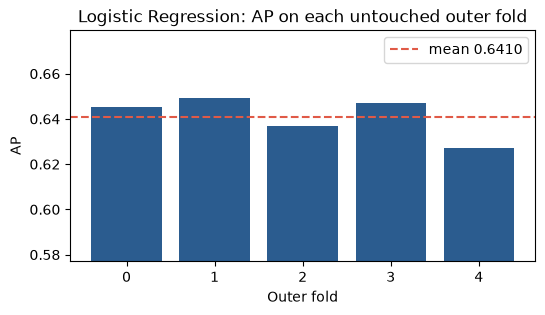

In [6]:
ap = per_fold['ap']
print(f'{MODEL}: AP {ap.mean():.4f} +/- {ap.std():.4f} (SD over 5 outer folds, ddof=1)')
print(f'pooled out-of-fold AP: {average_precision_score(y, oof):.4f}')
print('cancelled class at 0.5: precision {:.4f}, recall {:.4f}, F1 {:.4f}'.format(
    *per_fold[['precision', 'recall', 'f1']].mean()))

plt.figure(figsize=(6, 3))
plt.bar(per_fold['outer_fold'].astype(str), ap, color=palette[0])
plt.axhline(ap.mean(), color=palette[1], linestyle='--', label=f'mean {ap.mean():.4f}')
plt.ylim(max(0, ap.min() - 0.05), min(1, ap.max() + 0.03))
plt.xlabel('Outer fold')
plt.ylabel('AP')
plt.title(f'{MODEL}: AP on each untouched outer fold')
plt.legend()
plt.show()

## Save

`reports/results/v2/logistic_regression.csv`: one row per outer fold, then the mean and SD rows. `reports/results/v2/oof/logistic_regression.csv`: every training row's out-of-fold probability, aligned to `row_id`, for stages 9.4–9.6.

In [7]:
summary = per_fold.drop(columns=['outer_fold', 'best_params', 'model'])
out = pd.concat([
    per_fold.assign(outer_fold=per_fold['outer_fold'].astype(str)),
    summary.mean().to_frame().T.assign(model=MODEL, outer_fold='mean', best_params=''),
    summary.std().to_frame().T.assign(model=MODEL, outer_fold='sd', best_params=''),
], ignore_index=True)[per_fold.columns]

results = Path('../../reports/results/v2')
(results / 'oof').mkdir(parents=True, exist_ok=True)
out.to_csv(results / f'{SLUG}.csv', index=False)
pd.DataFrame({'row_id': folds.row_id, 'outer_fold': folds.outer_fold,
              'is_canceled': y, 'proba': oof}).to_csv(results / 'oof' / f'{SLUG}.csv', index=False)
out.round(4)

,model,outer_fold,ap,precision,recall,f1,inner_ap,best_params,search_seconds,refit_seconds,predict_seconds,n_fit,n_eval
0,Logistic Regression,0,0.6451,0.6651,0.4565,0.5414,0.6399,"{""model__C"": ""1""}",4.3622,0.9883,0.0449,54379.0000,13595.0000
1,Logistic Regression,1,0.6491,0.6673,0.4631,0.5468,0.6363,"{""model__C"": ""10""}",4.0033,1.0804,0.0544,54380.0000,13594.0000
2,Logistic Regression,2,0.6369,0.6464,0.4459,0.5278,0.6387,"{""model__C"": ""10""}",2.5654,0.9325,0.0294,54379.0000,13595.0000
3,Logistic Regression,3,0.6469,0.6715,0.4536,0.5415,0.6372,"{""model__C"": ""1""}",2.1696,0.7989,0.0461,54379.0000,13595.0000
4,Logistic Regression,4,0.6270,0.6440,0.4398,0.5227,0.6442,"{""model__C"": ""10""}",2.4642,0.9203,0.0465,54379.0000,13595.0000
5,Logistic Regression,mean,0.6410,0.6589,0.4518,0.5360,0.6393,,3.1129,0.9441,0.0443,54379.2000,13594.8000
6,Logistic Regression,sd,0.0091,0.0127,0.0091,0.0103,0.0031,,0.9955,0.1028,0.0091,0.4472,0.4472
